In [2]:
!pip install tslearn
!pip install torch pytorch-lightning pytorch-forecasting
!pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch.nn as nn
import torch

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline, GroupNormalizer
from pytorch_forecasting.data import NaNLabelEncoder
from torchmetrics.regression import MeanSquaredError as MSE
from pytorch_forecasting.metrics import RMSE
from lightning.pytorch import Trainer


/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/pytorch_forecasting/models/base_model.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Preprocessing

In [4]:
data_path = '/Users/laurenbeede/Google Drive/My Drive/STAT5243/FinalProject/Dexcom Data/'

csv_files = glob.glob(data_path + '*.csv')

df_list = []

for file in csv_files:
    df = pd.read_csv(file, skiprows=range(1, 11))
    df_list.append(df)

dexcom_df = pd.concat(df_list, ignore_index=True)

dexcom_df.shape

(339429, 14)

In [5]:
timeseries_data = dexcom_df[['Glucose Value (mg/dL)']]

dexcom_df.loc[dexcom_df['Glucose Value (mg/dL)'] == 'Low', 'Glucose Value (mg/dL)'] = 39
dexcom_df.loc[dexcom_df['Glucose Value (mg/dL)'] == 'High', 'Glucose Value (mg/dL)'] = 401

dexcom_df['Glucose Value (mg/dL)'] = dexcom_df['Glucose Value (mg/dL)'].astype(int)

dexcom_df['Timestamp'] = pd.to_datetime(dexcom_df['Timestamp (YYYY-MM-DDThh:mm:ss)'])

# Data was weird for these dates. Multiple records for same time points.
dates_to_remove = ['2023-11-21', '2024-02-14', '2024-08-07']
dates_to_remove = [pd.to_datetime(date).date() for date in dates_to_remove]
dexcom_df = dexcom_df[~dexcom_df['Timestamp'].dt.date.isin(dates_to_remove)]

## Creating a TimeSeriesDataSet

In [6]:
test_df = dexcom_df
test_df['day_id'] = test_df['Timestamp'].dt.date
test_df = test_df.sort_values(['day_id', 'Timestamp'])


In [7]:
test_df["time_idx"] = test_df.groupby("day_id").cumcount()
test_df["minute_of_day"] = test_df["Timestamp"].dt.hour * 60 + test_df["Timestamp"].dt.minute

In [8]:
# Set your encoder and prediction lengths; here encoder is one day (288 steps)
# and prediction horizon is next 12 steps (i.e., next hour).
max_encoder_length = 288
max_prediction_length = 12

In [9]:
# This will keep only groups (days) with at least 300 observations.
data = test_df.groupby("day_id").filter(lambda x: len(x) >= max_encoder_length + max_prediction_length)

Now the data is preprocessed in ```data```. We had to remove values with fewer than ```max_encoder_length + max_prediction_length``` because otherwise there is not enough observations to cover the required window.

In [10]:
# Define training cutoff – you will typically reserve the tail of each series for validation
training_cutoff = data["time_idx"].max() - max_prediction_length

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Glucose Value (mg/dL)",
    group_ids=["day_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_unknown_reals=["Glucose Value (mg/dL)"],
    time_varying_known_reals=["minute_of_day"],  # example of a known covariate 
    target_normalizer=GroupNormalizer(
        groups=["day_id"], transformation="relu"  # choose a normalization/transformation if needed
    ),
)


## Create DataLoaders

In [11]:
# Set your batch size (tune this based on your available GPU/CPU memory)
batch_size = 64

train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)

# Create a validation set from the full dataset using the already-defined training TimeSeriesDataSet.
# The predict=True flag ensures the dataset is set up for forecasting.
validation = TimeSeriesDataSet.from_dataset(
    training,  # the training TimeSeriesDataSet you defined earlier
    data,      # the full DataFrame including the validation period
    predict=True,  # sets up the dataset for prediction rather than training
    stop_randomization=True  # ensures reproducibility by removing randomization, useful for evaluation
)

val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)


## Configuring a model

In [12]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,           # size of hidden state in LSTM layers
    attention_head_size=1,    # number of attention heads
    dropout=0.1,              # dropout to control overfitting
    hidden_continuous_size=8, # for real-valued inputs
    output_size=1,            # single point estimate
    loss=RMSE(),      # loss function; can also experiment with other losses
    log_interval=10,
    reduce_on_plateau_patience=4,
)

/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [13]:
from lightning.pytorch import LightningModule
print(isinstance(tft, LightningModule))

True


## Train the model

In [14]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [15]:
from lightning.pytorch.callbacks import Callback

class MetricsLoggerCallback(Callback):
    def __init__(self):
        self.epoch_metrics = {"train_loss": [], "val_loss": []}  # add extra keys as needed

    def on_validation_epoch_end(self, trainer, pl_module):
        # Access metrics from the logger's callback metrics dictionary
        # Many Lightning callbacks log metrics to `trainer.callback_metrics`
        # Ensure the metrics are available here; sometimes you may access trainer.logged_metrics instead.
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        val_loss = metrics.get("val_loss")
        
        # Append to our list; cast to float if needed.
        self.epoch_metrics["train_loss"].append(float(train_loss) if train_loss is not None else None)
        self.epoch_metrics["val_loss"].append(float(val_loss) if val_loss is not None else None)
        
# Then, pass the callback to your Trainer:
metrics_logger = MetricsLoggerCallback()


In [16]:
trainer = Trainer(
    accelerator="mps",
    devices=1,
    max_epochs=20,
    callbacks=[metrics_logger]
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/pytorch_forecasting/models/temporal_fusion_transformer/_tft.py:724: UserWarning: MPS: nonzero op is supported natively starting from macOS 14.0. Falling back on CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/mps/operations/Indexing.mm:401.)
  decoder_attention[


/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 343/343 [04:08<00:00,  1.38it/s, v_num=2, train_loss_step=24.80, val_loss=26.90, train_loss_epoch=29.50]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 343/343 [04:09<00:00,  1.37it/s, v_num=2, train_loss_step=24.80, val_loss=26.90, train_loss_epoch=29.50]


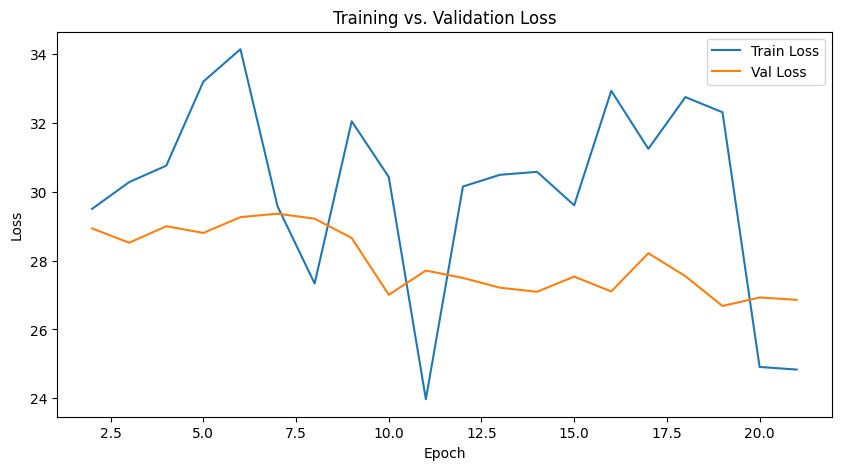

In [17]:
epochs = range(1, len(metrics_logger.epoch_metrics["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, metrics_logger.epoch_metrics["train_loss"], label="Train Loss")
plt.plot(epochs, metrics_logger.epoch_metrics["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.show()

## Test the model

In [18]:
# Suppose you want to predict for the tail part of your data
raw_predictions, x = tft.predict(val_dataloader, mode="raw", return_x=True)

# raw_predictions will contain the predicted quantiles or values; x contains the corresponding inputs


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/laurenbeede/blood_glucose_forecaster/env/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


ValueError: too many values to unpack (expected 2)